In [118]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [119]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

In [120]:
ticker='MSFT'
df=yf.download(ticker,'2020-01-01')

C:\Users\Workstation\AppData\Local\Temp\ipykernel_14924\1878050045.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,'2020-01-01')
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [121]:
df

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,152.791168,152.895807,150.612792,151.040856,22622100
2020-01-03,150.888611,152.153786,150.355908,150.603245,21116200
2020-01-06,151.278641,151.345236,148.881465,149.423690,20813700
2020-01-07,149.899338,151.887465,149.652016,151.554533,21634100
2020-01-08,152.286957,152.962357,150.251264,151.183494,27746500
...,...,...,...,...,...
2025-09-22,514.450012,517.739990,512.539978,515.590027,20009300
2025-09-23,509.230011,514.590027,507.309998,513.799988,19799600


<Axes: xlabel='Date'>

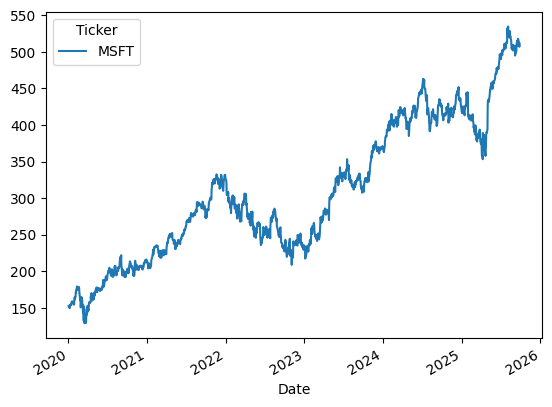

In [122]:
df.Close.plot()

In [123]:
scaler=StandardScaler()
df['Close']=scaler.fit_transform(df[['Close']])

In [124]:
df.Close

Ticker,MSFT
Date,
2020-01-02,-1.631312
2020-01-03,-1.651275
2020-01-06,-1.647182
2020-01-07,-1.661655
2020-01-08,-1.636602
...,...
2025-09-22,2.163512
2025-09-23,2.108739
2025-09-24,2.118392


In [125]:
seq_length=30
data=[]


for i in range(len(df)-seq_length):
    data.append(df.Close[i:i+seq_length])

data=np.array(data)

In [126]:
data

array([[[-1.63131175],
        [-1.65127496],
        [-1.64718244],
        ...,
        [-1.39355597],
        [-1.39086071],
        [-1.40084183]],

       [[-1.65127496],
        [-1.64718244],
        [-1.66165523],
        ...,
        [-1.39086071],
        [-1.40084183],
        [-1.38447241]],

       [[-1.64718244],
        [-1.66165523],
        [-1.63660236],
        ...,
        [-1.40084183],
        [-1.38447241],
        [-1.36570713]],

       ...,

       [[ 2.30958625],
        [ 2.21886788],
        [ 2.2387712 ],
        ...,
        [ 2.20002639],
        [ 2.16351156],
        [ 2.108739  ]],

       [[ 2.21886788],
        [ 2.2387712 ],
        [ 2.21457251],
        ...,
        [ 2.16351156],
        [ 2.108739  ],
        [ 2.11839222]],

       [[ 2.2387712 ],
        [ 2.21457251],
        [ 2.18241197],
        ...,
        [ 2.108739  ],
        [ 2.11839222],
        [ 2.08565465]]], shape=(1412, 30, 1))

In [127]:

train_size=int(0.8*len(data))
X_train=torch.from_numpy(data[:train_size, :-1,:]).type(torch.Tensor).to(device)
y_train=torch.from_numpy(data[:train_size, -1,:]).type(torch.Tensor).to(device)
X_test=torch.from_numpy(data[train_size:, :-1,:]).type(torch.Tensor).to(device)
y_test=torch.from_numpy(data[train_size:, -1,:]).type(torch.Tensor).to(device)

In [128]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        
        self.num_layers=num_layers
        self.hidden_dim=hidden_dim
        self.lstm=nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc=nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        h0=torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0=torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        
        out, (hn,cn)=self.lstm(x, (h0.detach(), c0.detach()))
        out=self.fc(out[:, -1, :])
        return out

In [129]:
model=PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [130]:
crit=nn.MSELoss()
opt=optim.Adam(model.parameters(), lr=0.01)

In [131]:
num_epochs=200

for i in range(num_epochs):
    y_train_pred=model(X_train)
    loss=crit(y_train_pred, y_train)

    if i%25==0:
        print(i,loss.item())
    
    opt.zero_grad()
    loss.backward()
    opt.step()

0 0.6982773542404175
25 0.011559093371033669
25 0.011559093371033669
50 0.004953321069478989
50 0.004953321069478989
75 0.004164107609540224
75 0.004164107609540224
100 0.0038754045963287354
100 0.0038754045963287354
125 0.0036531412042677402
125 0.0036531412042677402
150 0.0034563904628157616
150 0.0034563904628157616
175 0.0032802035566419363
175 0.0032802035566419363


In [132]:
model.eval()
y_test_pred=model(X_test)


y_train_pred=scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train=scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred=scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test=scaler.inverse_transform(y_test.detach().cpu().numpy())

In [133]:
train_rmse=root_mean_squared_error(y_train[:,0], y_train_pred[:,0])
test_rmse=root_mean_squared_error(y_test[:,0], y_test_pred[:,0])

In [134]:
train_rmse

5.332799434661865

In [135]:
test_rmse

9.914312362670898

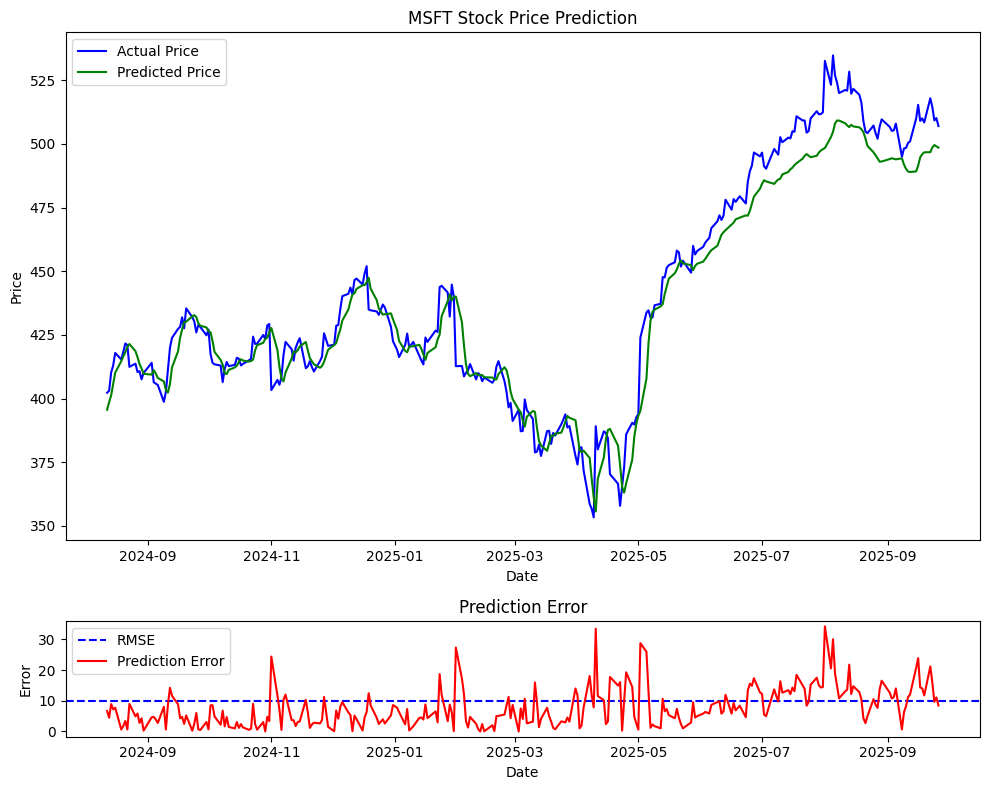

In [136]:
test_index = df.index[-len(y_test):]  # Get the index for the test set

fig=plt.figure(figsize=(10,8))
gs=fig.add_gridspec(4,1)
ax1=fig.add_subplot(gs[:3,0])
ax1.plot(test_index, y_test, label='Actual Price', color='blue')
ax1.plot(test_index, y_test_pred, label='Predicted Price', color='green')
ax1.legend()
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')

ax2=fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color='blue', label='RMSE', linestyle='--')
ax2.plot(test_index, abs(y_test - y_test_pred), label='Prediction Error', color='red')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()

The error is caused by using a tuple as a column name in your DataFrame. Your DataFrame `df` has multi-level column names (e.g., `('Close', 'MSFT')`). When you use `df.Close`, it does not select the correct column. You should use `df[('Close', 'MSFT')]` instead.



Made changes.